# Surrogate Modeling of a Binary Distillation Column
## Benzene-Toluene System | Peng-Robinson EOS | Physics-Based Simulation Data

**Objective:** Develop and compare ML surrogate models to predict:
- xD (distillate purity), xB (bottoms purity), QC (condenser duty), QR (reboiler duty)

**Models compared:**
1. Polynomial Regression (degree 2 + Ridge)
2. Random Forest Regressor
3. XGBoost / Gradient Boosting Regressor
4. Support Vector Regression (SVR - RBF)
5. Artificial Neural Network (MLP)

---

## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('XGBoost available:', xgb.__version__)
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not found - will use GradientBoostingRegressor')

plt.rcParams.update({
    'figure.dpi': 110,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
SEED = 42
np.random.seed(SEED)

os.makedirs(os.path.join('..', 'results'), exist_ok=True)
print('Setup complete.')

XGBoost available: 3.2.0
Setup complete.


---
## 1. Data Loading & EDA

In [2]:
DATA_PATH = os.path.join('..', 'data', 'dataset.csv')
df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Dataset shape: (694, 20)
Columns: ['feed_temperature_K', 'feed_pressure_kPa', 'feed_composition_benzene', 'n_stages', 'feed_stage', 'reflux_ratio', 'bottoms_rate_kmol_h', 'feed_vapor_fraction_q', 'column_pressure_kPa', 'relative_volatility', 'R_over_Rmin', 'N_over_Nmin', 'feed_stage_fraction', 'distillate_rate_kmol_h', 'bubble_point_T_K', 'dew_point_T_K', 'xD_benzene', 'xB_benzene', 'QC_kW', 'QR_kW']


,feed_temperature_K,feed_pressure_kPa,feed_composition_benzene,n_stages,feed_stage,reflux_ratio,bottoms_rate_kmol_h,feed_vapor_fraction_q,column_pressure_kPa,relative_volatility,R_over_Rmin,N_over_Nmin,feed_stage_fraction,distillate_rate_kmol_h,bubble_point_T_K,dew_point_T_K,xD_benzene,xB_benzene,QC_kW,QR_kW
0,357.895,202.650,0.4714,10,3,2.0714,30.0,-0.01304,202.650,7.78328,2.60849,1.39156,0.30,70.0,360.419,390.990,0.717153,0.000001,2655.7962,2802.3972
1,328.421,121.590,0.5857,15,6,2.0714,30.0,-0.02720,121.590,11.01593,1.87505,17.19526,0.40,70.0,333.686,366.525,0.729698,0.249752,2055.1809,2131.1992
2,395.789,101.325,0.3571,10,5,2.6429,70.0,1.08914,101.325,5.50023,1.38905,7.14727,0.50,30.0,341.482,371.478,0.728410,0.198029,953.8081,992.4682
3,370.526,152.000,0.3571,25,17,2.3571,46.0,0.47259,152.000,6.84744,2.83375,3.22563,0.68,54.0,356.984,385.640,0.749389,0.000001,1934.6177,2046.3776
4,395.789,101.325,0.4143,10,3,3.5000,30.0,1.09801,101.325,5.50023,2.15538,1.14533,0.30,70.0,337.332,369.059,0.744433,0.000001,2745.6918,2902.9981


In [3]:
print('=== Descriptive Statistics ===')
df.describe().round(4)

=== Descriptive Statistics ===


,feed_temperature_K,feed_pressure_kPa,feed_composition_benzene,n_stages,feed_stage,reflux_ratio,bottoms_rate_kmol_h,feed_vapor_fraction_q,column_pressure_kPa,relative_volatility,R_over_Rmin,N_over_Nmin,feed_stage_fraction,distillate_rate_kmol_h,bubble_point_T_K,dew_point_T_K,xD_benzene,xB_benzene,QC_kW,QR_kW
count,694.0000,694.000,694.0000,694.0000,694.0000,694.0000,694.0000,694.0000,694.000,694.0000,694.0000,694.0000,694.0000,694.0000,694.0000,694.0000,694.0000,694.0000,694.0000,694.0000
mean,358.2423,142.952,0.4869,19.7695,9.8833,2.4895,49.3659,0.4509,142.952,8.2311,2.9501,14.0837,0.4995,50.6341,345.1727,375.8812,0.7474,0.1739,1809.1144,1891.7875
std,25.1616,38.902,0.1232,6.7571,5.8743,0.6223,13.3081,0.4800,38.902,2.1866,1.1593,9.4100,0.2118,13.3081,13.2043,11.5817,0.0301,0.1280,623.8587,660.6008
min,320.0000,101.325,0.3000,10.0000,3.0000,1.5000,30.0000,-0.2000,101.325,5.3390,0.6834,1.1328,0.1000,30.0000,321.7710,353.3730,0.7000,0.0000,655.9625,676.0567
25%,336.5600,121.590,0.3787,15.0000,5.0000,2.0535,38.0000,-0.0341,121.590,6.3562,1.9972,4.5583,0.3000,38.0000,333.8178,366.5915,0.7215,0.0000,1341.3870,1393.4500
50%,356.2980,121.590,0.4714,20.0000,8.0000,2.3571,47.0445,0.4470,121.590,7.8996,2.9112,13.4961,0.5000,52.9555,344.0740,374.1530,0.7456,0.2137,1728.8156,1797.3712
75%,378.9470,202.650,0.5857,25.0000,13.7500,2.9531,62.0000,1.0037,202.650,9.9344,3.7213,20.6683,0.6800,62.0000,353.4120,384.5790,0.7708,0.3000,2220.4738,2308.2024
max,400.0000,202.650,0.7000,30.0000,27.0000,3.5000,70.0000,1.1539,202.650,12.4550,7.2980,42.2083,0.9000,70.0000,373.6640,398.9910,0.8246,0.3000,3875.7149,4105.7024


In [4]:
print('Missing values:', df.isnull().sum().sum())
print('\nData types:')
print(df.dtypes)

Missing values: 0

Data types:
feed_temperature_K          float64
feed_pressure_kPa           float64
feed_composition_benzene    float64
n_stages                      int64
feed_stage                    int64
reflux_ratio                float64
bottoms_rate_kmol_h         float64
feed_vapor_fraction_q       float64
column_pressure_kPa         float64
relative_volatility         float64
R_over_Rmin                 float64
N_over_Nmin                 float64
feed_stage_fraction         float64
distillate_rate_kmol_h      float64
bubble_point_T_K            float64
dew_point_T_K               float64
xD_benzene                  float64
xB_benzene                  float64
QC_kW                       float64
QR_kW                       float64
dtype: object


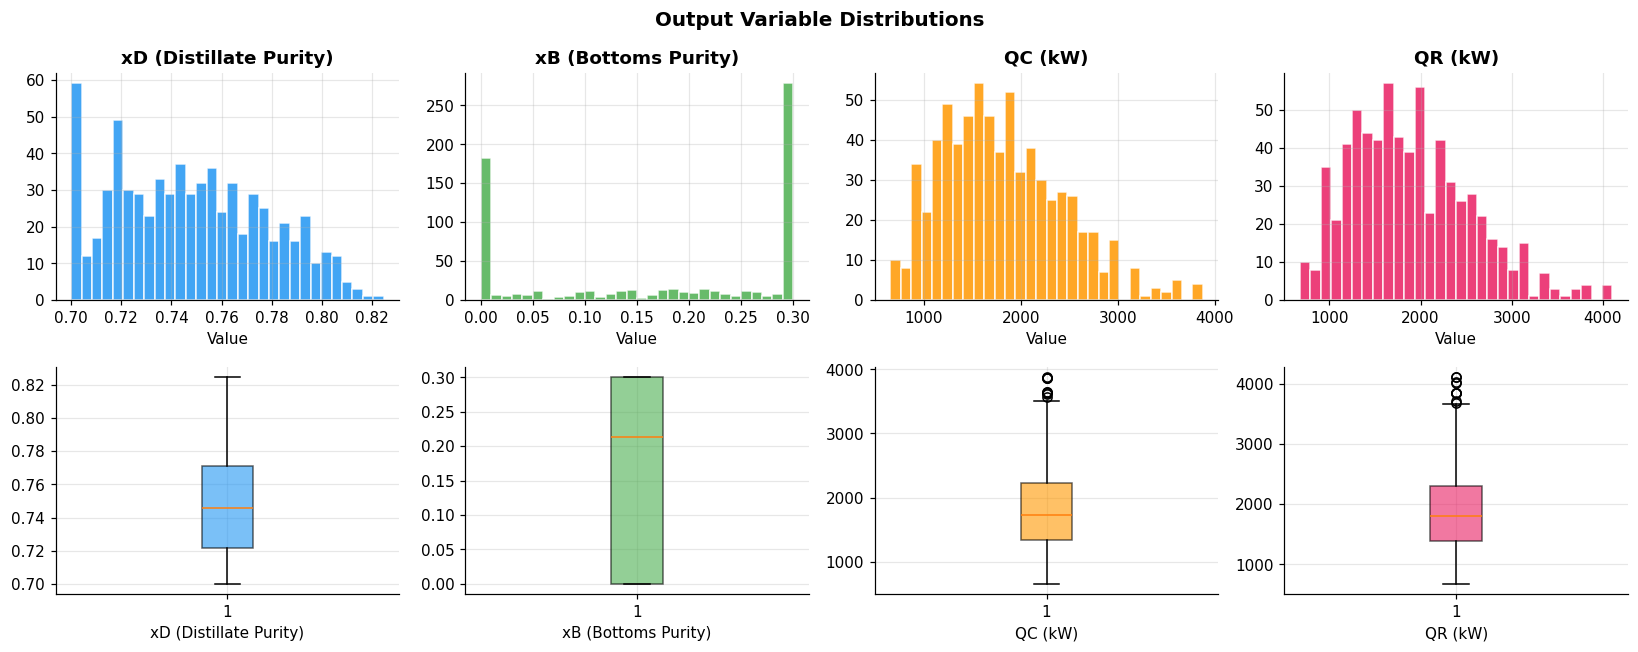

In [5]:
# Output variable distributions
targets = ['xD_benzene', 'xB_benzene', 'QC_kW', 'QR_kW']
target_labels = ['xD (Distillate Purity)', 'xB (Bottoms Purity)', 'QC (kW)', 'QR (kW)']

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for i, (t, lbl) in enumerate(zip(targets, target_labels)):
    axes[0, i].hist(df[t], bins=30, color=PALETTE[i], alpha=0.85, edgecolor='white')
    axes[0, i].set_title(lbl, fontweight='bold')
    axes[0, i].set_xlabel('Value')
    axes[1, i].boxplot(df[t], vert=True, patch_artist=True,
                       boxprops=dict(facecolor=PALETTE[i], alpha=0.6))
    axes[1, i].set_xlabel(lbl)
plt.suptitle('Output Variable Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'results', 'output_distributions.png'), bbox_inches='tight')
plt.show()

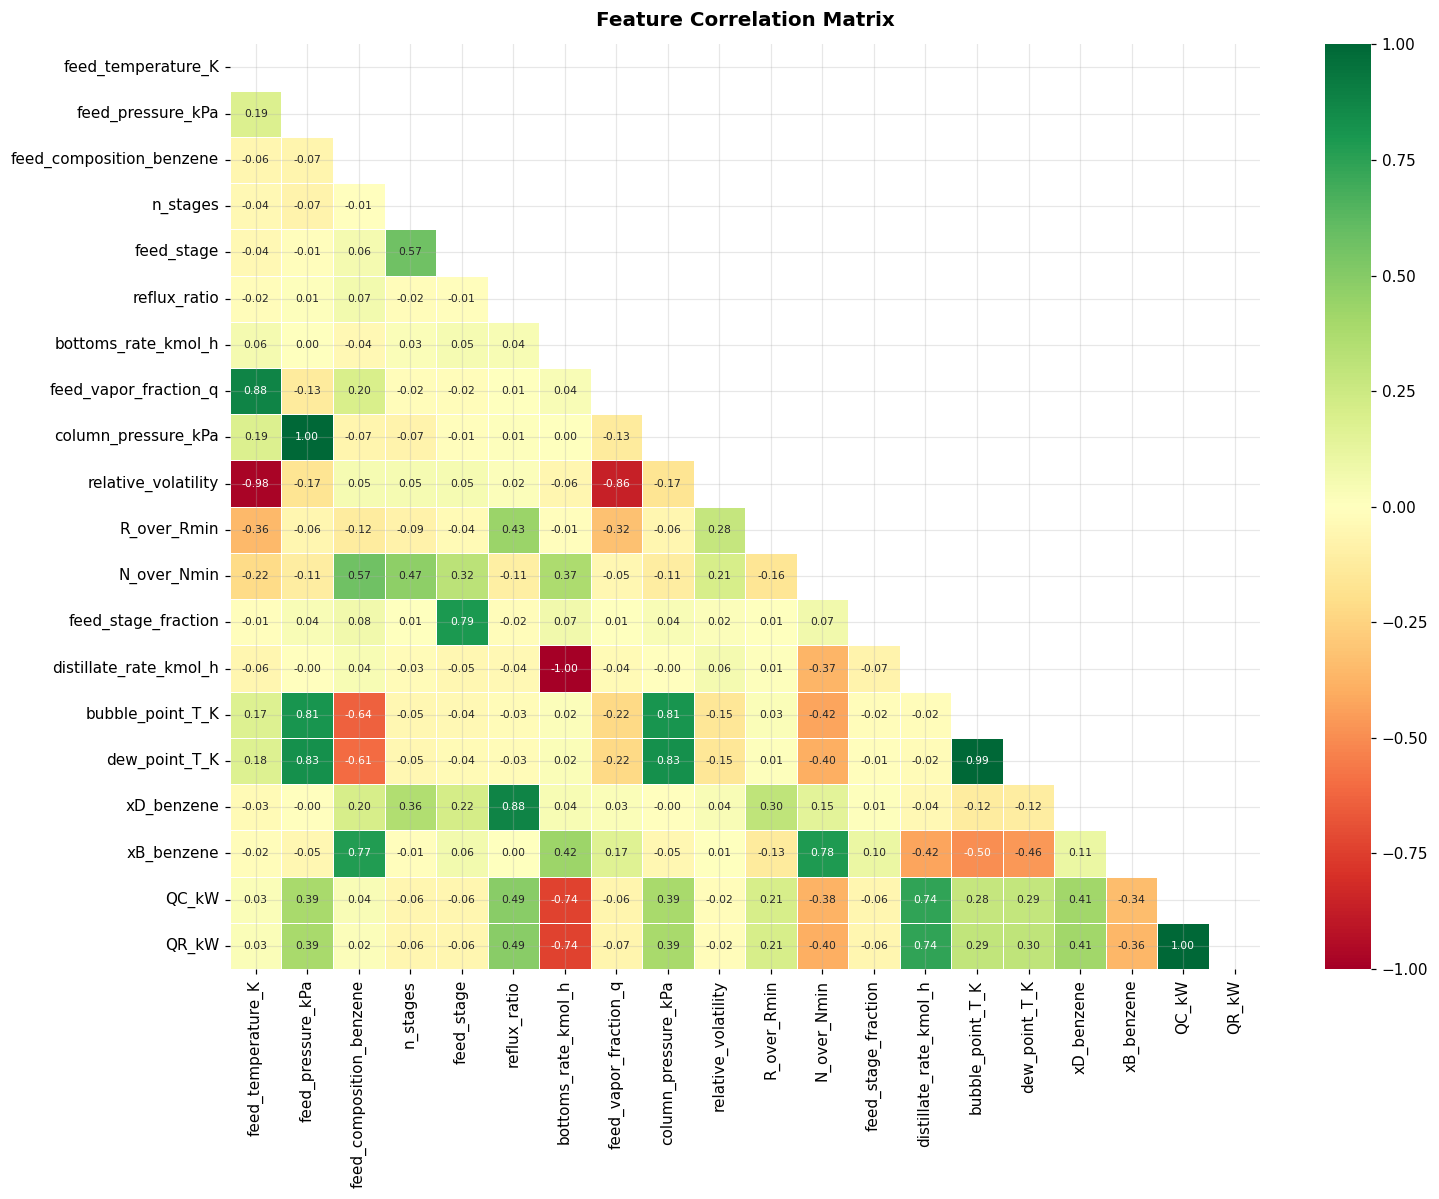

In [6]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 11))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(os.path.join('..', 'results', 'correlation_heatmap.png'), bbox_inches='tight')
plt.show()

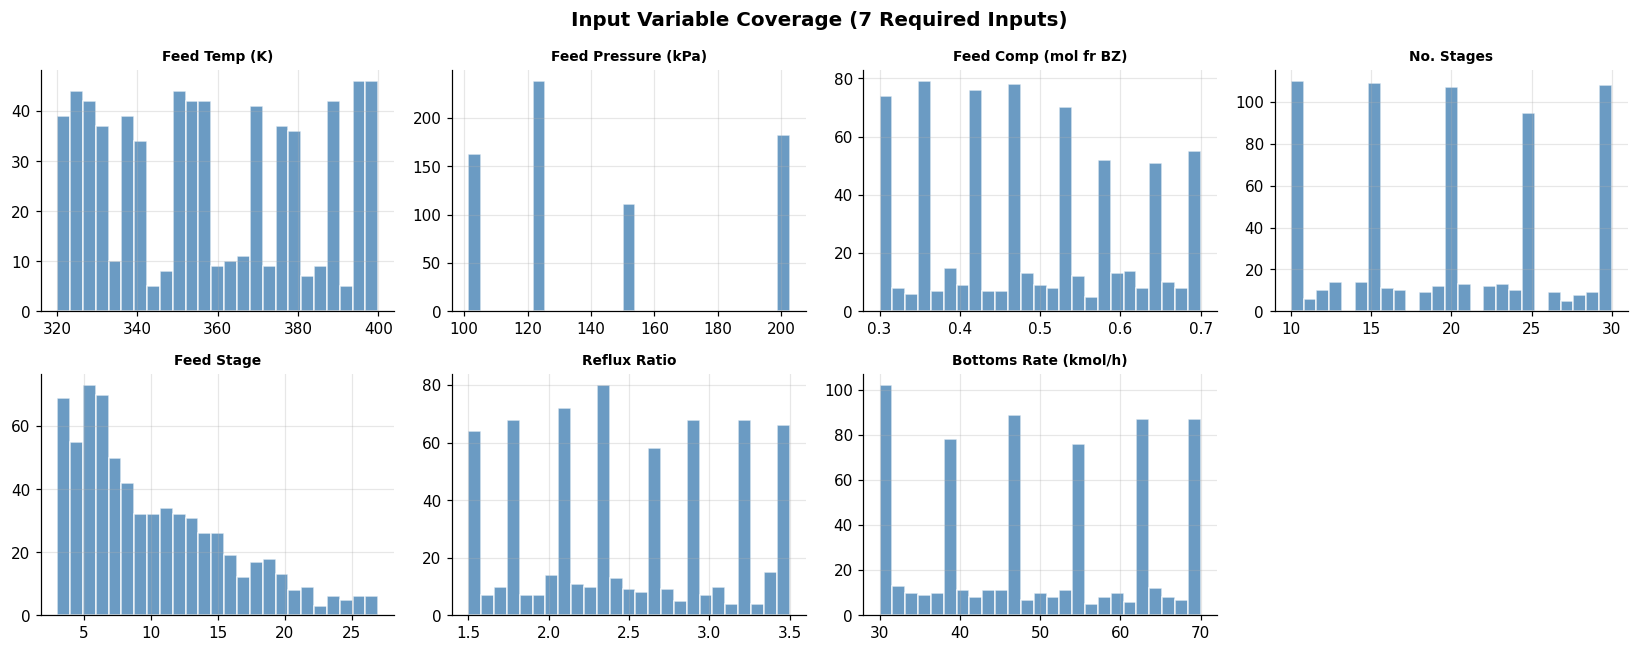

In [7]:
# Input variable distributions
primary_inputs = ['feed_temperature_K','feed_pressure_kPa','feed_composition_benzene',
                   'n_stages','feed_stage','reflux_ratio','bottoms_rate_kmol_h']
input_labels   = ['Feed Temp (K)','Feed Pressure (kPa)','Feed Comp (mol fr BZ)',
                   'No. Stages','Feed Stage','Reflux Ratio','Bottoms Rate (kmol/h)']

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.flatten()
for i, (col, lbl) in enumerate(zip(primary_inputs, input_labels)):
    axes[i].hist(df[col], bins=25, color='steelblue', alpha=0.8, edgecolor='white')
    axes[i].set_title(lbl, fontweight='bold', fontsize=9)
axes[-1].set_visible(False)
plt.suptitle('Input Variable Coverage (7 Required Inputs)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'results', 'input_distributions.png'), bbox_inches='tight')
plt.show()

---
## 2. Data Preprocessing

In [8]:
# Feature / Target split
FEATURE_COLS = [
    # 7 required inputs
    'feed_temperature_K',
    'feed_pressure_kPa',
    'feed_composition_benzene',
    'n_stages',
    'feed_stage',
    'reflux_ratio',
    'bottoms_rate_kmol_h',
    # Additional physically meaningful derived features
    'feed_vapor_fraction_q',
    'relative_volatility',
    'R_over_Rmin',
    'N_over_Nmin',
    'feed_stage_fraction',
    'distillate_rate_kmol_h',
]

TARGET_COLS = ['xD_benzene', 'xB_benzene', 'QC_kW', 'QR_kW']
TARGET_DISPLAY = ['xD (Distillate Purity)', 'xB (Bottoms Purity)', 'QC (kW)', 'QR (kW)']

X_all = df[FEATURE_COLS].values
y_all = df[TARGET_COLS].values   # raw targets - NO log transform to keep it simple & avoid NaN/inf

print('Features:', X_all.shape)
print('Targets: ', y_all.shape)
print('NaN in X:', np.isnan(X_all).sum())
print('NaN in y:', np.isnan(y_all).sum())
print('Inf in y:', np.isinf(y_all).sum())

Features: (694, 13)
Targets:  (694, 4)
NaN in X: 0
NaN in y: 0
Inf in y: 0


In [9]:
# Train / validation / test split  70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED)

print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test.shape)

# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Target scaling (for ANN)
target_scaler = StandardScaler()
y_train_sc = target_scaler.fit_transform(y_train)
y_val_sc   = target_scaler.transform(y_val)
y_test_sc  = target_scaler.transform(y_test)

print('Scaling done.')

Train: (485, 13) | Val: (104, 13) | Test: (105, 13)
Scaling done.


In [10]:
# Helper: compute metrics per target
def compute_metrics(y_true, y_pred, model_name):
    """Compute MAE, RMSE, R2 for each of the 4 targets."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    # Replace any inf/nan in prediction with 0 to avoid crashes
    y_pred = np.where(np.isfinite(y_pred), y_pred, 0.0)
    results = {'Model': model_name}
    col_tags = ['xD', 'xB', 'QC', 'QR']
    for i, tag in enumerate(col_tags):
        mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        r2   = r2_score(y_true[:, i], y_pred[:, i])
        results[tag + '_MAE']  = round(mae,  6)
        results[tag + '_RMSE'] = round(rmse, 6)
        results[tag + '_R2']   = round(r2,   6)
    return results

model_results = {}   # name -> metrics dict
model_preds   = {}   # name -> (y_true, y_pred) on test set
print('Helpers ready.')

Helpers ready.


---
## 3. Model 1: Polynomial Regression (degree=2)

In [11]:
print('=== Polynomial Regression (degree=2, Ridge) ===')

y_pred_poly = np.zeros_like(y_test)
poly_pipes = {}

for i, tgt in enumerate(TARGET_COLS):
    pipe = Pipeline([
        ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
        ('ridge', Ridge(alpha=10.0))
    ])
    pipe.fit(X_train_sc, y_train[:, i])
    y_pred_poly[:, i] = pipe.predict(X_test_sc)
    poly_pipes[tgt] = pipe

res_poly = compute_metrics(y_test, y_pred_poly, 'Polynomial Regression')
model_results['Polynomial Regression'] = res_poly
model_preds['Polynomial Regression']   = (y_test.copy(), y_pred_poly.copy())

print('Results:')
for tag in ['xD','xB','QC','QR']:
    print(f'  {tag}: R2={res_poly[tag+"_R2"]:.4f}  MAE={res_poly[tag+"_MAE"]:.5f}  RMSE={res_poly[tag+"_RMSE"]:.5f}')

=== Polynomial Regression (degree=2, Ridge) ===
Results:
  xD: R2=0.9940  MAE=0.00192  RMSE=0.00248
  xB: R2=0.9658  MAE=0.01756  RMSE=0.02264
  QC: R2=0.9989  MAE=16.86954  RMSE=22.25876
  QR: R2=0.9990  MAE=17.44144  RMSE=22.91449


In [12]:
# 5-fold cross-validation for polynomial regression
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
print('5-Fold CV R2 (Polynomial Regression):')
for i, tgt in enumerate(TARGET_COLS):
    cv = cross_val_score(poly_pipes[tgt], X_train_sc, y_train[:, i], cv=kf, scoring='r2')
    print(f'  {tgt:30s}: {cv.mean():.4f} +/- {cv.std():.4f}')

5-Fold CV R2 (Polynomial Regression):


  xD_benzene                    : 0.9926 +/- 0.0008


  xB_benzene                    : 0.9623 +/- 0.0073
  QC_kW                         : 0.9983 +/- 0.0002


  QR_kW                         : 0.9984 +/- 0.0001


---
## 4. Model 2: Random Forest Regressor

In [13]:
print('=== Random Forest Regressor ===')

rf_model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=200, max_depth=None,
        min_samples_split=4, min_samples_leaf=2,
        max_features='sqrt', n_jobs=-1, random_state=SEED
    )
)
rf_model.fit(X_train_sc, y_train)
y_pred_rf = rf_model.predict(X_test_sc)

res_rf = compute_metrics(y_test, y_pred_rf, 'Random Forest')
model_results['Random Forest'] = res_rf
model_preds['Random Forest']   = (y_test.copy(), y_pred_rf.copy())

for tag in ['xD','xB','QC','QR']:
    print(f'  {tag}: R2={res_rf[tag+"_R2"]:.4f}  MAE={res_rf[tag+"_MAE"]:.5f}  RMSE={res_rf[tag+"_RMSE"]:.5f}')

=== Random Forest Regressor ===


  xD: R2=0.9173  MAE=0.00714  RMSE=0.00919
  xB: R2=0.9221  MAE=0.02537  RMSE=0.03418
  QC: R2=0.9180  MAE=137.48795  RMSE=193.06790
  QR: R2=0.9192  MAE=140.72466  RMSE=201.95215


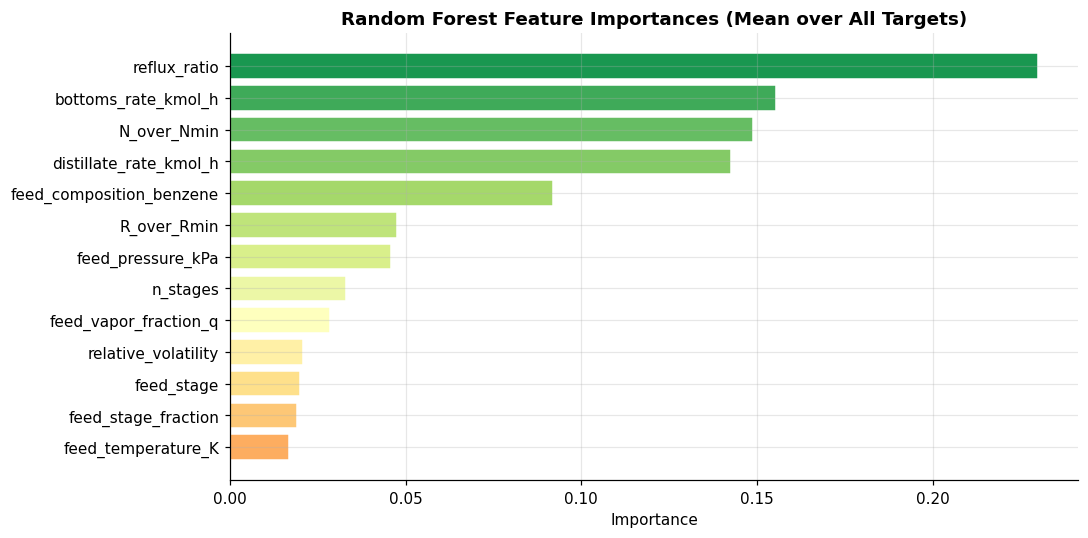

Top 5 features:
reflux_ratio                0.229879
bottoms_rate_kmol_h         0.155322
N_over_Nmin                 0.148854
distillate_rate_kmol_h      0.142508
feed_composition_benzene    0.091844
dtype: float64


In [14]:
# Feature importance from Random Forest
importances = np.mean([est.feature_importances_ for est in rf_model.estimators_], axis=0)
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_imp)))
ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors, edgecolor='white')
ax.set_title('Random Forest Feature Importances (Mean over All Targets)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join('..', 'results', 'feature_importance_rf.png'), bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(feat_imp.head())

---
## 5. Model 3: XGBoost / Gradient Boosting

In [15]:
print('=== XGBoost / Gradient Boosting ===')

y_pred_xgb = np.zeros_like(y_test)

if XGB_AVAILABLE:
    xgb_model = MultiOutputRegressor(
        xgb.XGBRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=SEED, verbosity=0, n_jobs=-1
        )
    )
    xgb_model.fit(X_train_sc, y_train)
    y_pred_xgb = xgb_model.predict(X_test_sc)
    model_label = 'XGBoost'
else:
    gb_models = {}
    for i, tgt in enumerate(TARGET_COLS):
        gb = GradientBoostingRegressor(
            n_estimators=200, max_depth=5, learning_rate=0.08,
            subsample=0.8, random_state=SEED
        )
        gb.fit(X_train_sc, y_train[:, i])
        y_pred_xgb[:, i] = gb.predict(X_test_sc)
        gb_models[tgt] = gb
    model_label = 'Gradient Boosting'

res_xgb = compute_metrics(y_test, y_pred_xgb, model_label)
model_results[model_label] = res_xgb
model_preds[model_label]   = (y_test.copy(), y_pred_xgb.copy())

for tag in ['xD','xB','QC','QR']:
    print(f'  {tag}: R2={res_xgb[tag+"_R2"]:.4f}  MAE={res_xgb[tag+"_MAE"]:.5f}  RMSE={res_xgb[tag+"_RMSE"]:.5f}')

=== XGBoost / Gradient Boosting ===


  xD: R2=0.9768  MAE=0.00352  RMSE=0.00487
  xB: R2=0.9767  MAE=0.01217  RMSE=0.01869
  QC: R2=0.9834  MAE=58.75044  RMSE=86.75513
  QR: R2=0.9816  MAE=63.66288  RMSE=96.44771


---
## 6. Model 4: Support Vector Regression (SVR)

In [16]:
print('=== SVR (RBF kernel) ===')

y_pred_svr = np.zeros_like(y_test)
svr_params_list = [
    {'C': 100,  'epsilon': 0.0005, 'gamma': 'scale'},  # xD
    {'C': 50,   'epsilon': 0.0001, 'gamma': 'scale'},  # xB
    {'C': 1000, 'epsilon': 2.0,    'gamma': 'scale'},  # QC
    {'C': 1000, 'epsilon': 2.0,    'gamma': 'scale'},  # QR
]

for i, (tgt, params) in enumerate(zip(TARGET_COLS, svr_params_list)):
    svr = SVR(kernel='rbf', **params)
    svr.fit(X_train_sc, y_train[:, i])
    y_pred_svr[:, i] = svr.predict(X_test_sc)
    r2 = r2_score(y_test[:, i], y_pred_svr[:, i])
    print(f'  {tgt:30s}: R2={r2:.4f}')

res_svr = compute_metrics(y_test, y_pred_svr, 'SVR (RBF)')
model_results['SVR (RBF)'] = res_svr
model_preds['SVR (RBF)']   = (y_test.copy(), y_pred_svr.copy())
print('Done.')

=== SVR (RBF kernel) ===
  xD_benzene                    : R2=0.9903


  xB_benzene                    : R2=0.9816


  QC_kW                         : R2=0.9896


  QR_kW                         : R2=0.9895
Done.


---
## 7. Model 5: Artificial Neural Network (MLP)

In [17]:
print('=== ANN / MLP Regressor ===')

ann = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate='adaptive',
    learning_rate_init=5e-4,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=SEED,
    batch_size=32,
)

# Train on scaled targets → inverse-transform predictions back to original scale
ann.fit(X_train_sc, y_train_sc)
y_pred_ann_sc = ann.predict(X_test_sc)
y_pred_ann    = target_scaler.inverse_transform(y_pred_ann_sc)

res_ann = compute_metrics(y_test, y_pred_ann, 'ANN (MLP)')
model_results['ANN (MLP)'] = res_ann
model_preds['ANN (MLP)']   = (y_test.copy(), y_pred_ann.copy())

print(f'Iterations: {ann.n_iter_}')
for tag in ['xD','xB','QC','QR']:
    print(f'  {tag}: R2={res_ann[tag+"_R2"]:.4f}  MAE={res_ann[tag+"_MAE"]:.5f}  RMSE={res_ann[tag+"_RMSE"]:.5f}')

=== ANN / MLP Regressor ===


Iterations: 134
  xD: R2=0.9918  MAE=0.00224  RMSE=0.00290
  xB: R2=0.9879  MAE=0.01003  RMSE=0.01349
  QC: R2=0.9963  MAE=29.72290  RMSE=40.82239
  QR: R2=0.9966  MAE=31.66679  RMSE=41.21536


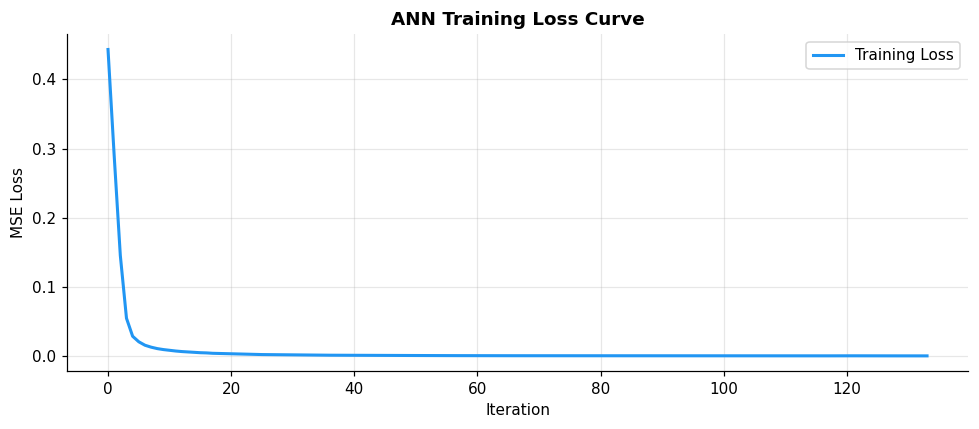

In [18]:
# ANN training loss curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ann.loss_curve_, color='#2196F3', linewidth=2, label='Training Loss')
ax.set_xlabel('Iteration')
ax.set_ylabel('MSE Loss')
ax.set_title('ANN Training Loss Curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join('..', 'results', 'ann_loss_curve.png'), bbox_inches='tight')
plt.show()

---
## 8. Model Comparison

In [19]:
# Build metrics DataFrame
metrics_df = pd.DataFrame(list(model_results.values())).set_index('Model')
metrics_df['avg_R2']   = metrics_df[['xD_R2','xB_R2','QC_R2','QR_R2']].mean(axis=1)
metrics_df['avg_RMSE'] = metrics_df[['xD_RMSE','xB_RMSE','QC_RMSE','QR_RMSE']].mean(axis=1)
metrics_df['avg_MAE']  = metrics_df[['xD_MAE','xB_MAE','QC_MAE','QR_MAE']].mean(axis=1)

print('=== Model Comparison – Test Set Metrics ===')
display_cols = ['xD_R2','xB_R2','QC_R2','QR_R2','avg_R2','avg_RMSE','avg_MAE']
print(metrics_df[display_cols].sort_values('avg_R2', ascending=False).round(4).to_string())

metrics_df.round(6).to_csv(os.path.join('..', 'results', 'model_metrics.csv'))
print('\nSaved to results/model_metrics.csv')

=== Model Comparison – Test Set Metrics ===
                        xD_R2   xB_R2   QC_R2   QR_R2  avg_R2  avg_RMSE  avg_MAE
Model                                                                           
ANN (MLP)              0.9918  0.9879  0.9963  0.9966  0.9932   20.5135  15.3505
Polynomial Regression  0.9940  0.9658  0.9989  0.9990  0.9894   11.2996   8.5826
SVR (RBF)              0.9903  0.9816  0.9896  0.9895  0.9877   35.4286  21.3363
XGBoost                0.9768  0.9767  0.9834  0.9816  0.9796   45.8066  30.6073
Random Forest          0.9173  0.9221  0.9180  0.9192  0.9192   98.7659  69.5613

Saved to results/model_metrics.csv


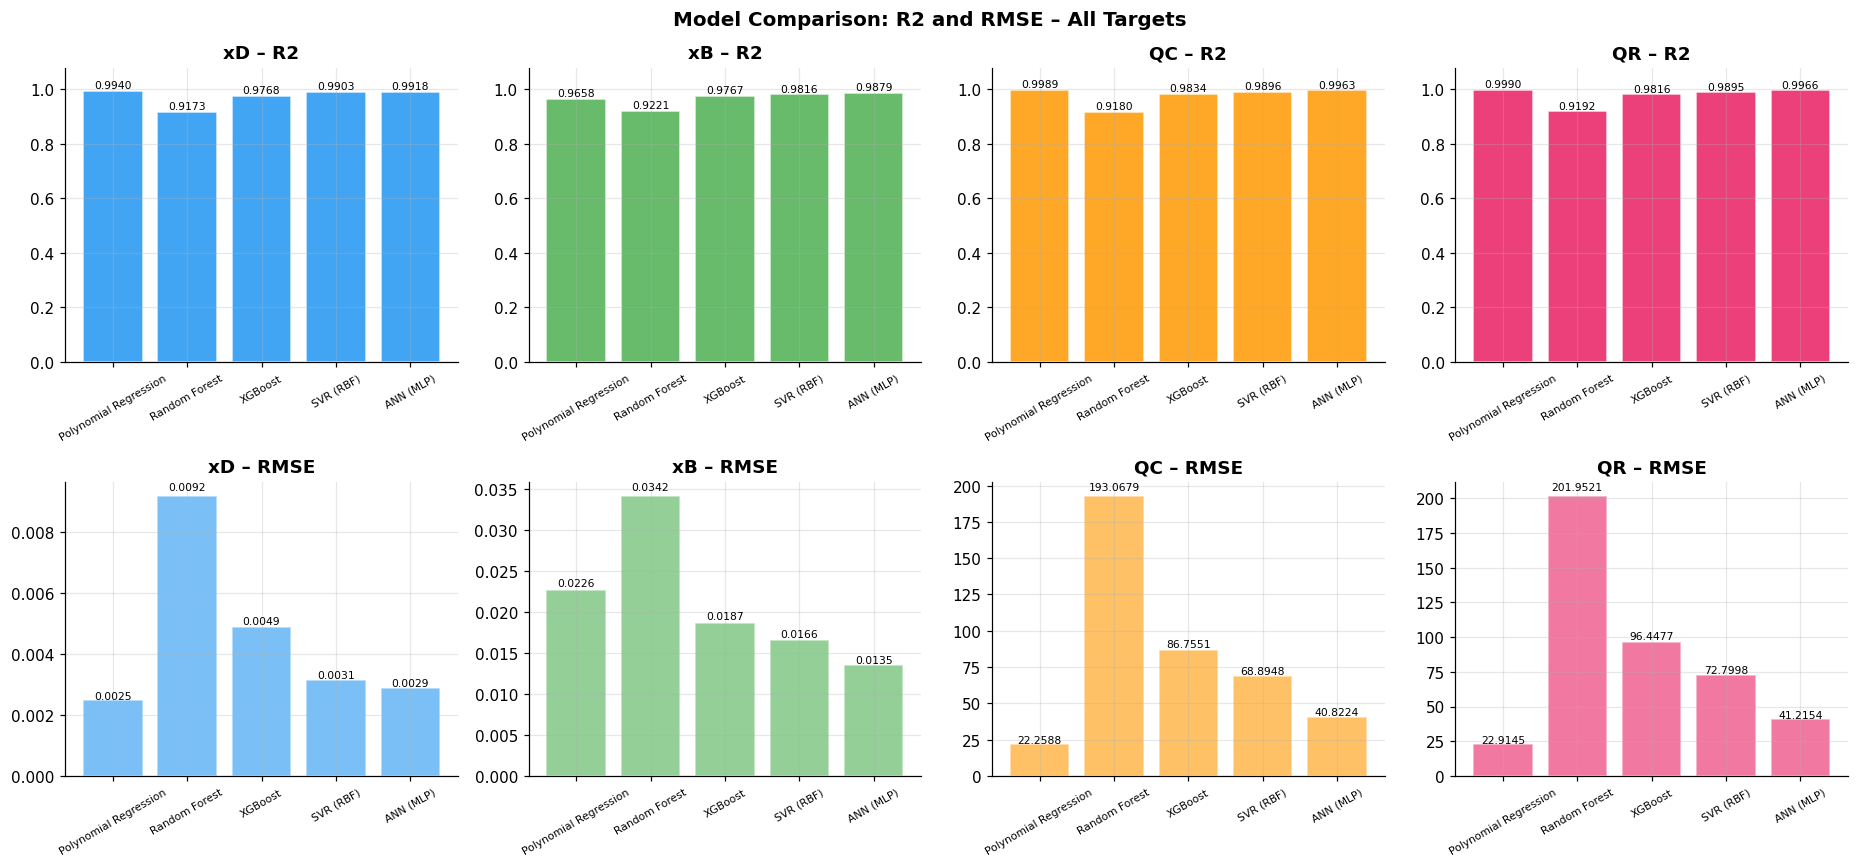

In [20]:
# R2 and RMSE bar chart comparison
model_names = list(model_results.keys())
target_vars = ['xD', 'xB', 'QC', 'QR']

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for j, tvar in enumerate(target_vars):
    r2s   = [model_results[m][tvar+'_R2']   for m in model_names]
    rmses = [model_results[m][tvar+'_RMSE'] for m in model_names]

    bars1 = axes[0, j].bar(model_names, r2s, color=PALETTE[j], alpha=0.85, edgecolor='white')
    axes[0, j].set_title(f'{tvar} – R2', fontweight='bold')
    axes[0, j].set_ylim(0, 1.08)
    axes[0, j].tick_params(axis='x', rotation=30, labelsize=7)
    for bar, v in zip(bars1, r2s):
        axes[0, j].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        '%.4f' % v, ha='center', fontsize=7)

    bars2 = axes[1, j].bar(model_names, rmses, color=PALETTE[j], alpha=0.6, edgecolor='white')
    axes[1, j].set_title(f'{tvar} – RMSE', fontweight='bold')
    axes[1, j].tick_params(axis='x', rotation=30, labelsize=7)
    for bar, v in zip(bars2, rmses):
        axes[1, j].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                        '%.4f' % v, ha='center', fontsize=7)

plt.suptitle('Model Comparison: R2 and RMSE – All Targets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'results', 'model_comparison_metrics.png'), bbox_inches='tight')
plt.show()

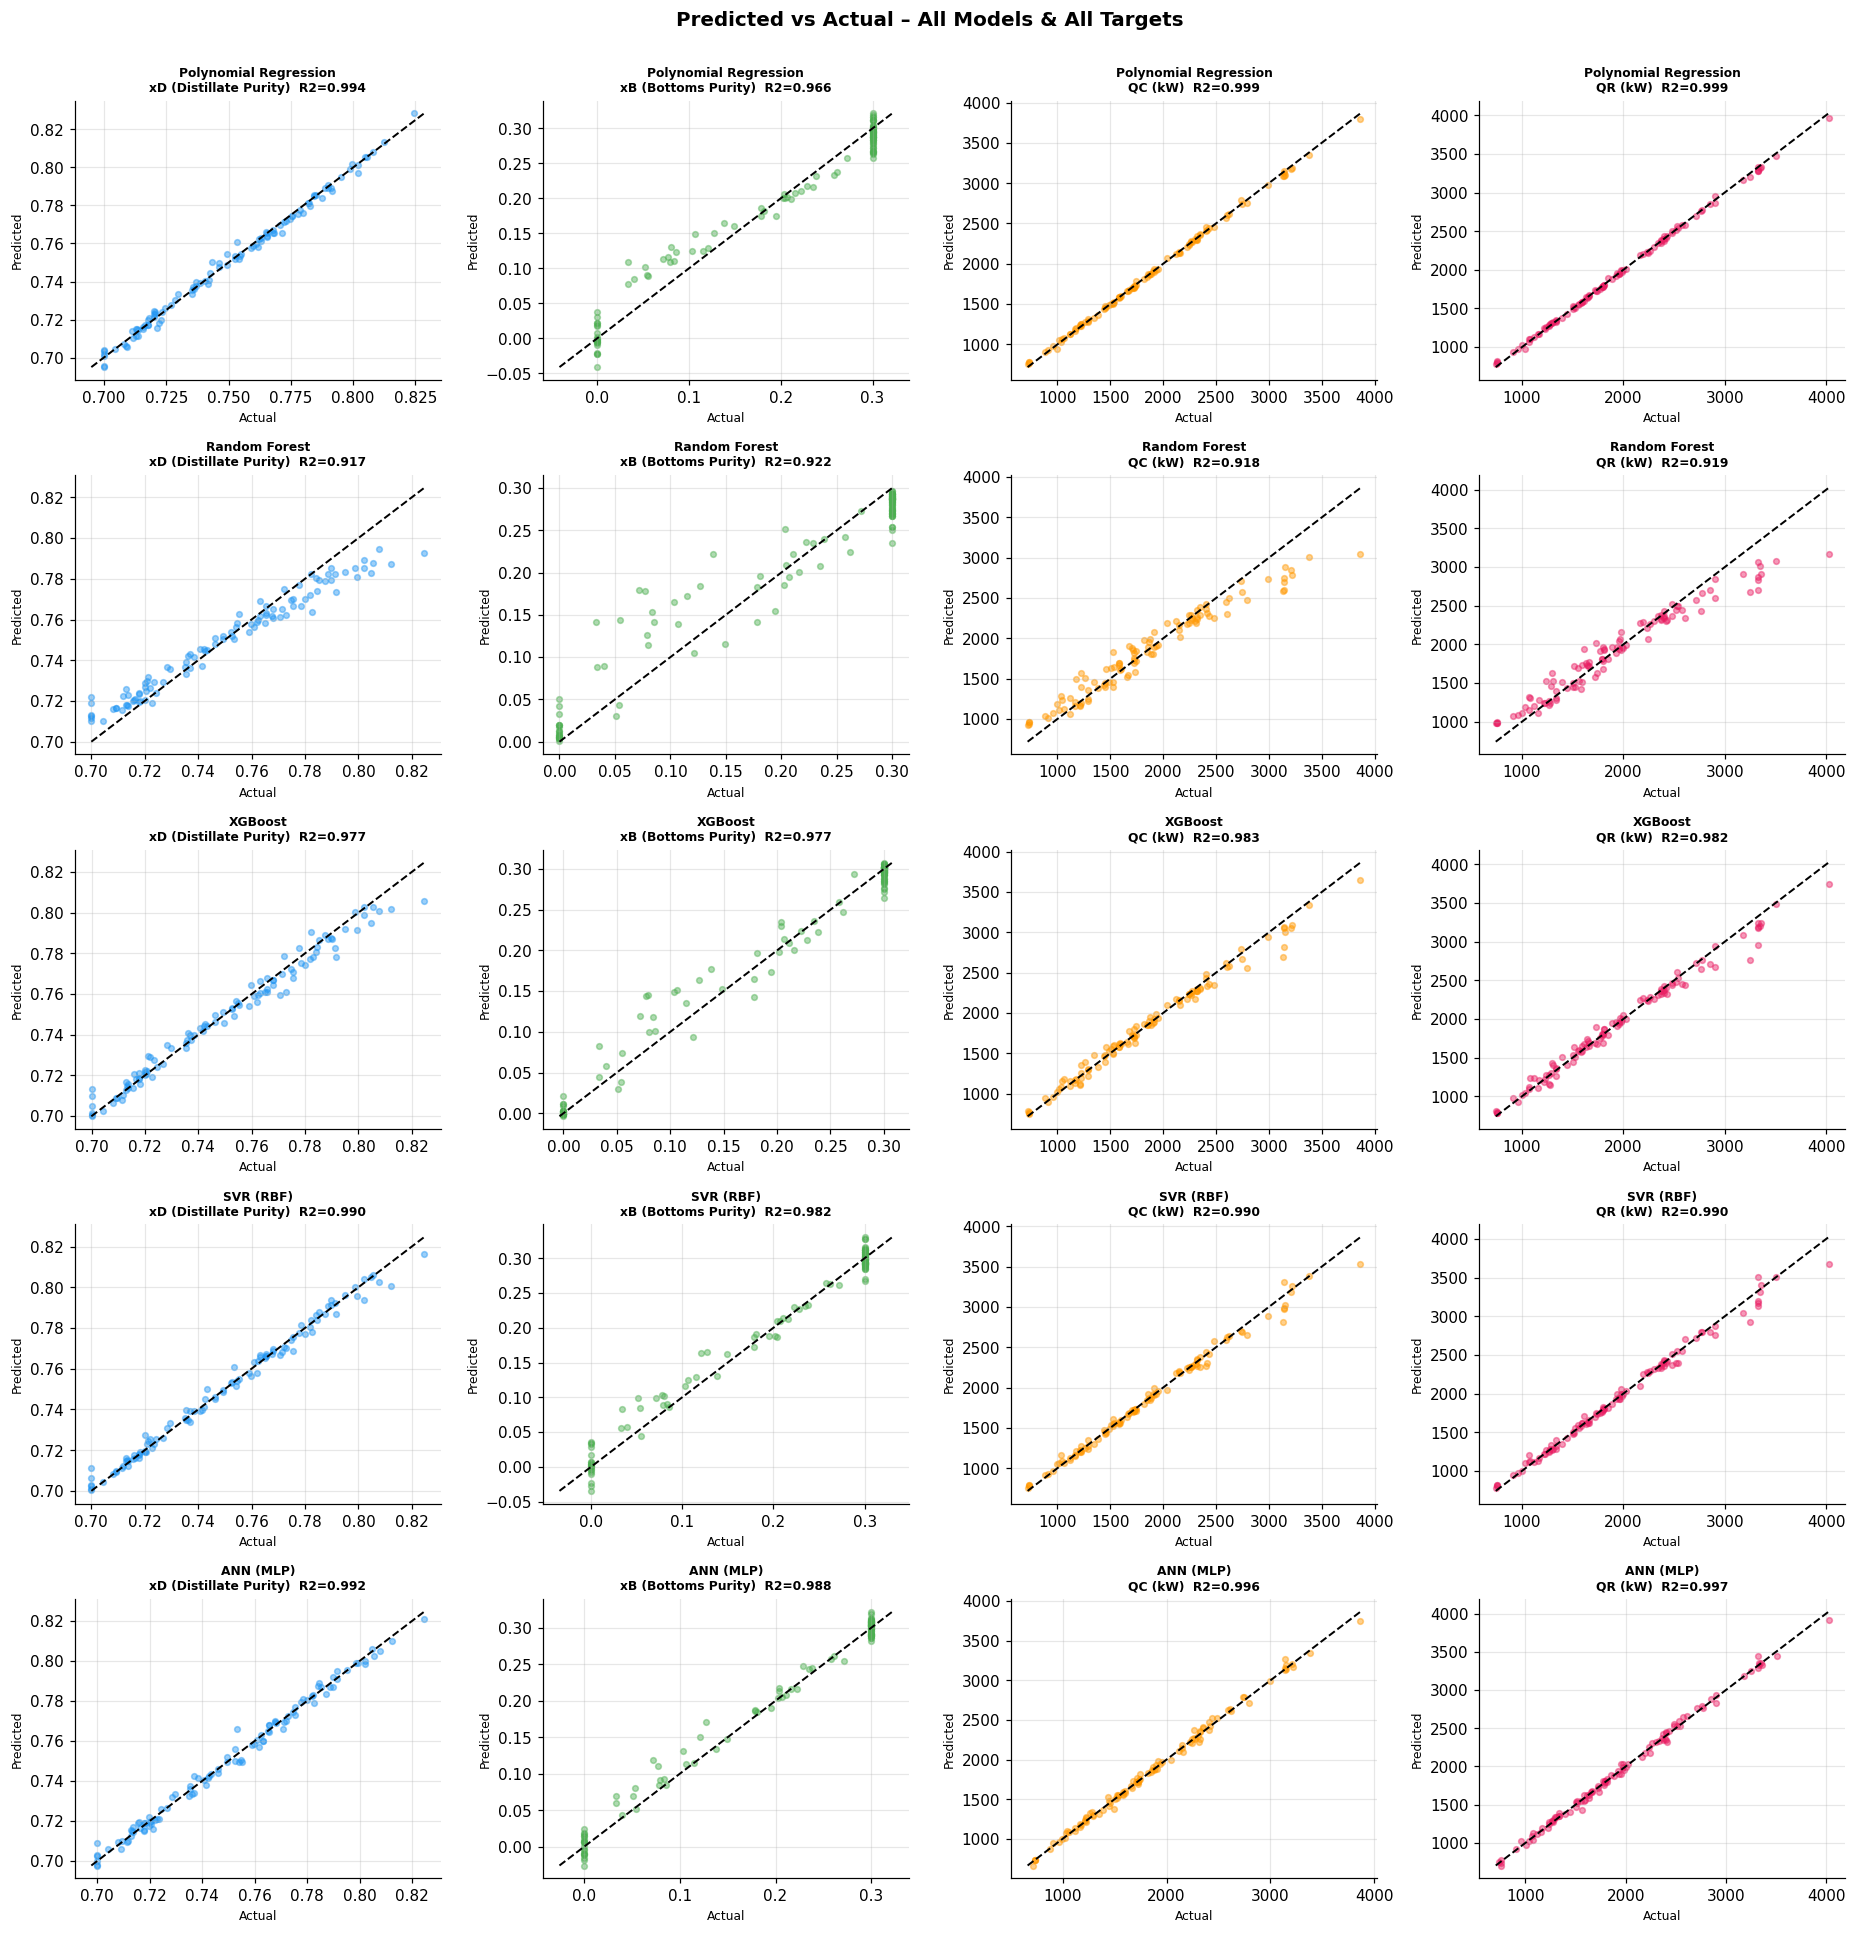

In [21]:
# Predicted vs Actual scatter plots (all models, all targets)
fig, axes = plt.subplots(len(model_names), 4, figsize=(17, 3.5 * len(model_names)))
for row, mname in enumerate(model_names):
    yt, yp = model_preds[mname]
    yp = np.where(np.isfinite(yp), yp, 0.0)
    for col in range(4):
        ax = axes[row, col]
        ax.scatter(yt[:, col], yp[:, col], alpha=0.45, s=14, color=PALETTE[col])
        lo = min(yt[:, col].min(), yp[:, col].min())
        hi = max(yt[:, col].max(), yp[:, col].max())
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.3)
        r2 = r2_score(yt[:, col], yp[:, col])
        ax.set_title(f'{mname}\n{TARGET_DISPLAY[col]}  R2={r2:.3f}', fontsize=8, fontweight='bold')
        ax.set_xlabel('Actual', fontsize=8)
        ax.set_ylabel('Predicted', fontsize=8)

plt.suptitle('Predicted vs Actual – All Models & All Targets', fontsize=13, fontweight='bold', y=1.002)
plt.tight_layout()
plt.savefig(os.path.join('..', 'results', 'predicted_vs_actual.png'), bbox_inches='tight')
plt.show()

Best model by avg R2: ANN (MLP)


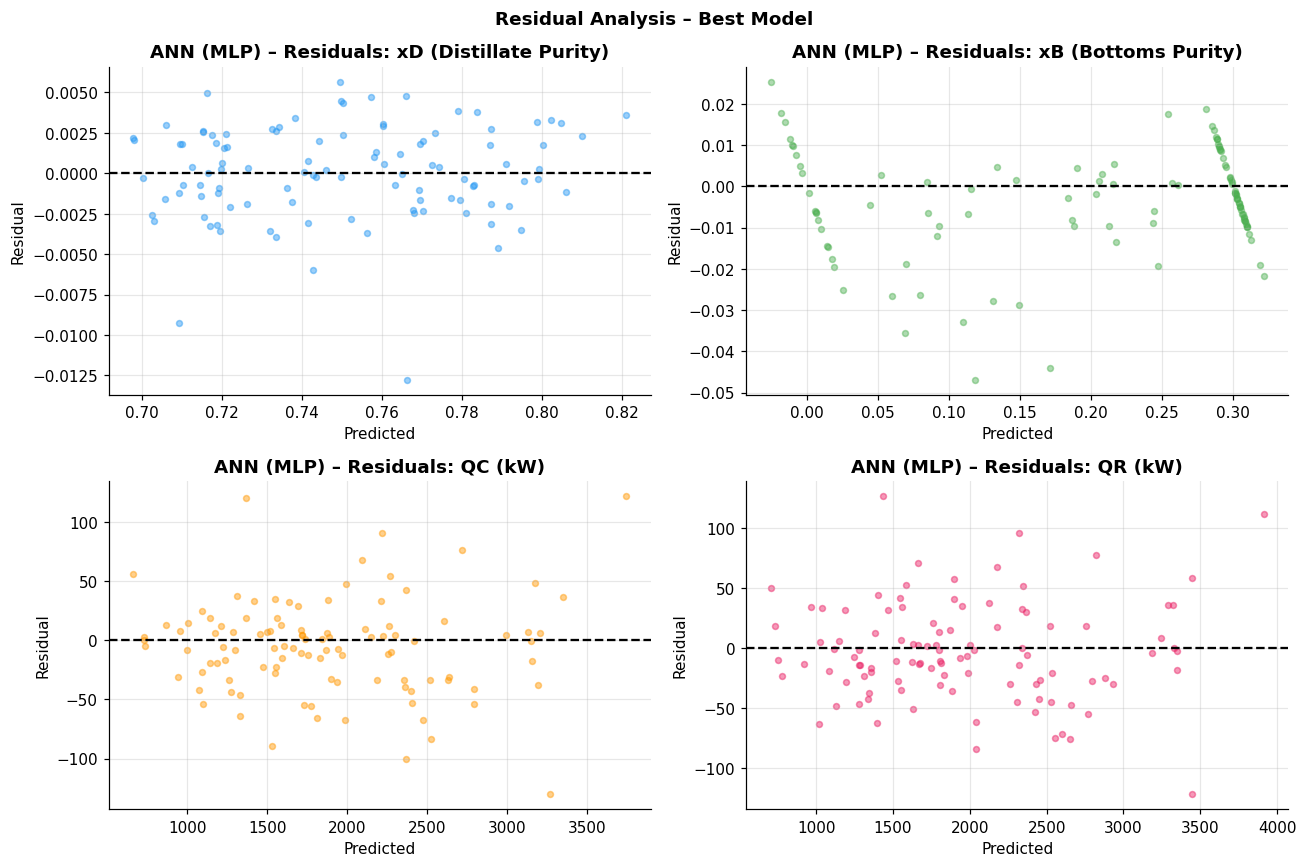

In [22]:
# Best model residual plots
best_model_name = sorted(model_results.keys(),
                         key=lambda m: model_results[m]['xD_R2'] + model_results[m]['xB_R2'] +
                                        model_results[m]['QC_R2'] + model_results[m]['QR_R2'],
                         reverse=True)[0]
print('Best model by avg R2:', best_model_name)

yt_b, yp_b = model_preds[best_model_name]
yp_b = np.where(np.isfinite(yp_b), yp_b, 0.0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, lbl in enumerate(TARGET_DISPLAY):
    residuals = yt_b[:, i] - yp_b[:, i]
    axes[i].scatter(yp_b[:, i], residuals, alpha=0.45, s=15, color=PALETTE[i])
    axes[i].axhline(0, color='black', linewidth=1.5, linestyle='--')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Residual')
    axes[i].set_title(f'{best_model_name} – Residuals: {lbl}', fontweight='bold')

plt.suptitle('Residual Analysis – Best Model', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'results', 'residual_plots.png'), bbox_inches='tight')
plt.show()

---
## 9. Physical Consistency & Sensitivity Analysis

In [23]:
# Median input point as baseline for trend analysis
X_median_sc = np.median(X_train_sc, axis=0).reshape(1, -1)
reflux_idx = FEATURE_COLS.index('reflux_ratio')
temp_idx   = FEATURE_COLS.index('feed_temperature_K')
n_idx      = FEATURE_COLS.index('n_stages')
zF_idx     = FEATURE_COLS.index('feed_composition_benzene')

rf_base = rf_model  # use Random Forest for trend analysis (always available)

def predict_trend(base_sc, vary_idx, values_orig, scaler_obj):
    """Vary one feature over a range, predict with RF model."""
    preds = []
    std = scaler_obj.mean_[vary_idx]
    scl = scaler_obj.scale_[vary_idx]
    for v in values_orig:
        x = base_sc.copy()
        x[0, vary_idx] = (v - std) / scl
        preds.append(rf_base.predict(x)[0])
    return np.array(preds)  # shape (n_vals, 4)

print('Trend analysis helper ready.')

Trend analysis helper ready.


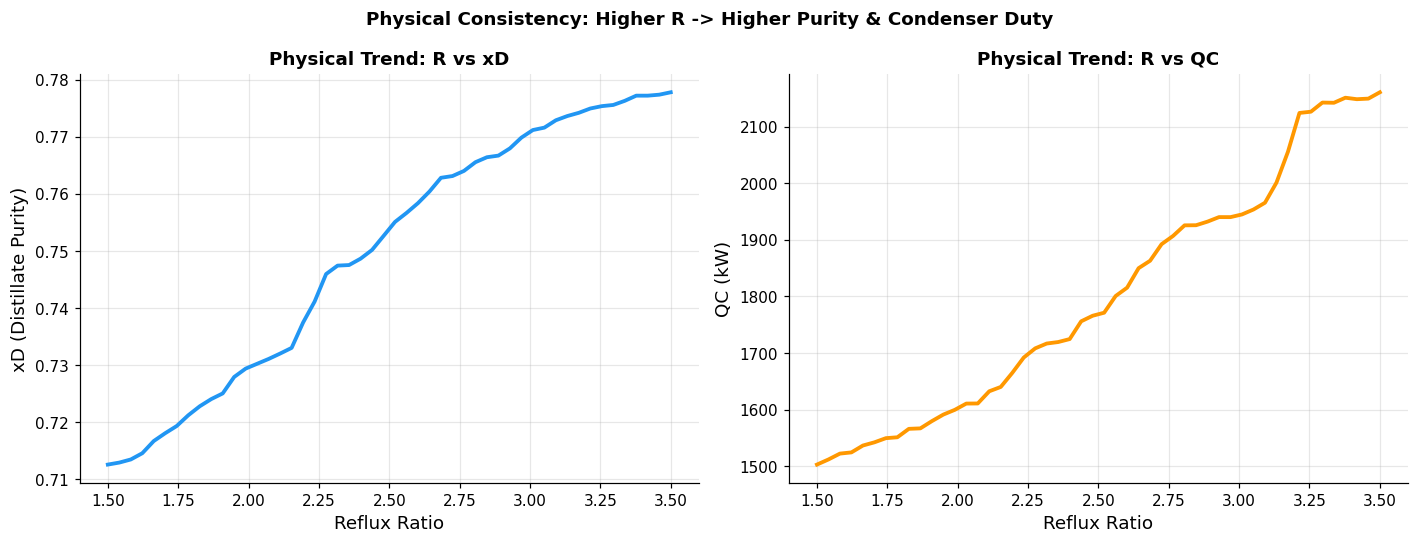

xD monotonically non-decreasing with R: True
QC monotonically non-decreasing with R: False


In [24]:
# Trend: Reflux Ratio vs xD and QC
R_range = np.linspace(1.5, 3.5, 50)
preds_R = predict_trend(X_median_sc, reflux_idx, R_range, scaler)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(R_range, preds_R[:, 0], color='#2196F3', linewidth=2.5)
axes[0].set_xlabel('Reflux Ratio', fontsize=12)
axes[0].set_ylabel('xD (Distillate Purity)', fontsize=12)
axes[0].set_title('Physical Trend: R vs xD', fontweight='bold')

axes[1].plot(R_range, preds_R[:, 2], color='#FF9800', linewidth=2.5)
axes[1].set_xlabel('Reflux Ratio', fontsize=12)
axes[1].set_ylabel('QC (kW)', fontsize=12)
axes[1].set_title('Physical Trend: R vs QC', fontweight='bold')

plt.suptitle('Physical Consistency: Higher R -> Higher Purity & Condenser Duty', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'results', 'trend_reflux_ratio.png'), bbox_inches='tight')
plt.show()

mono_xD = all(np.diff(preds_R[:, 0]) >= -1e-5)
mono_QC = all(np.diff(preds_R[:, 2]) >= -1e-5)
print('xD monotonically non-decreasing with R:', mono_xD)
print('QC monotonically non-decreasing with R:', mono_QC)

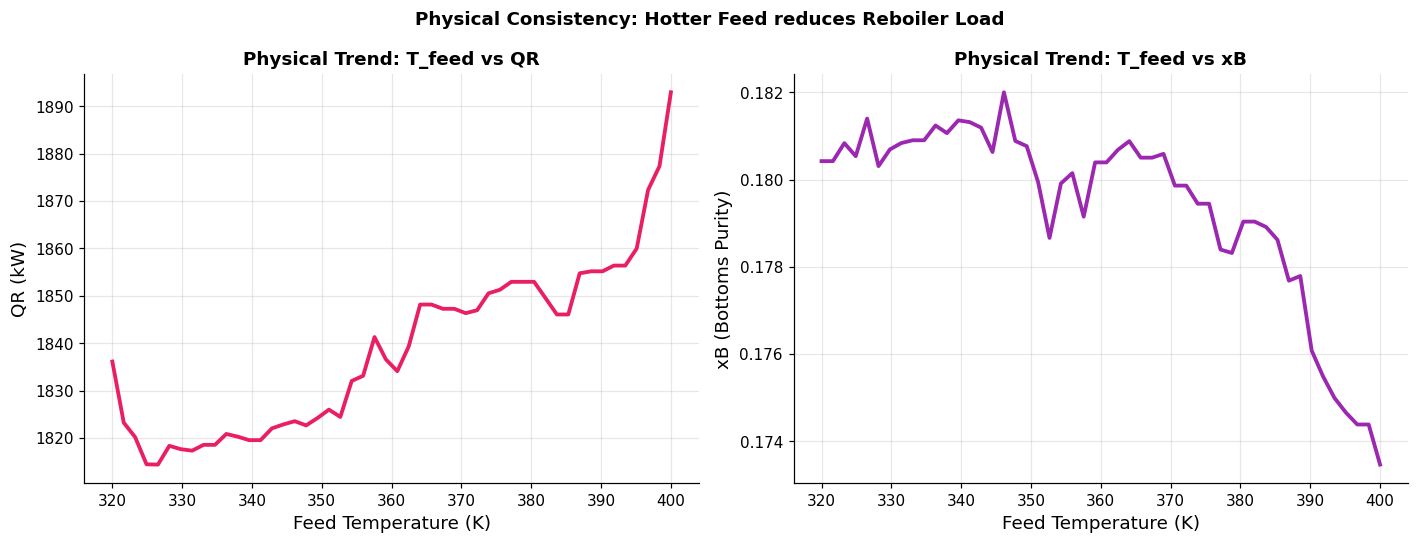

In [25]:
# Trend: Feed Temperature vs QR and xB
T_range = np.linspace(320, 400, 50)
preds_T = predict_trend(X_median_sc, temp_idx, T_range, scaler)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(T_range, preds_T[:, 3], color='#E91E63', linewidth=2.5)
axes[0].set_xlabel('Feed Temperature (K)', fontsize=12)
axes[0].set_ylabel('QR (kW)', fontsize=12)
axes[0].set_title('Physical Trend: T_feed vs QR', fontweight='bold')

axes[1].plot(T_range, preds_T[:, 1], color='#9C27B0', linewidth=2.5)
axes[1].set_xlabel('Feed Temperature (K)', fontsize=12)
axes[1].set_ylabel('xB (Bottoms Purity)', fontsize=12)
axes[1].set_title('Physical Trend: T_feed vs xB', fontweight='bold')

plt.suptitle('Physical Consistency: Hotter Feed reduces Reboiler Load', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'results', 'trend_feed_temperature.png'), bbox_inches='tight')
plt.show()

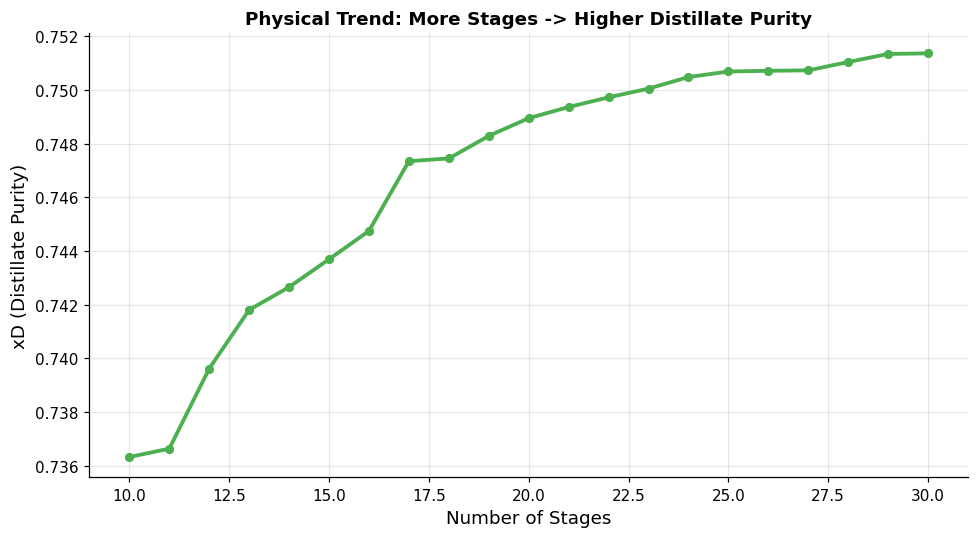

In [26]:
# Trend: Number of Stages vs xD
N_range = np.arange(10, 31)
preds_N = predict_trend(X_median_sc, n_idx, N_range, scaler)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(N_range, preds_N[:, 0], color='#4CAF50', linewidth=2.5, marker='o', markersize=5)
ax.set_xlabel('Number of Stages', fontsize=12)
ax.set_ylabel('xD (Distillate Purity)', fontsize=12)
ax.set_title('Physical Trend: More Stages -> Higher Distillate Purity', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'results', 'trend_n_stages.png'), bbox_inches='tight')
plt.show()

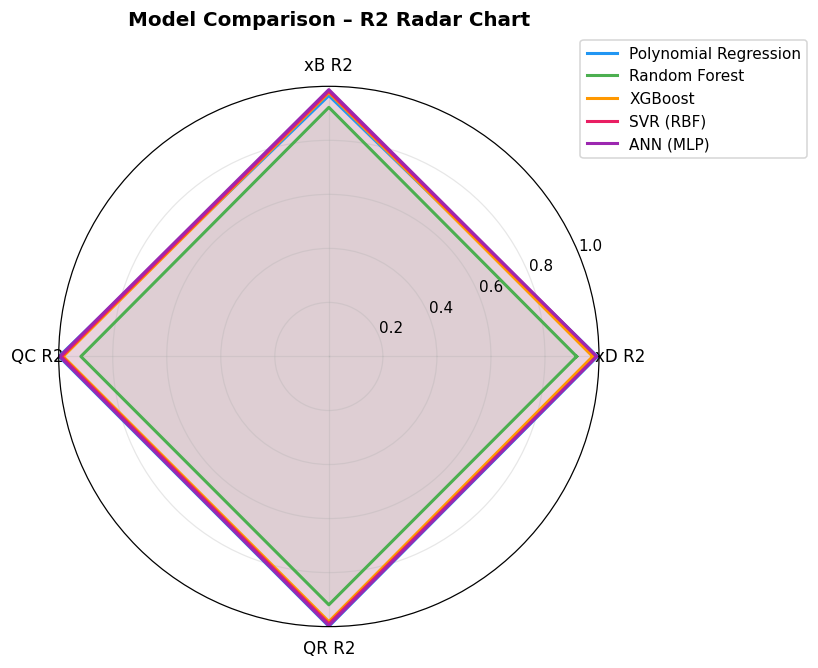

In [27]:
# Radar chart model comparison
categories = ['xD R2', 'xB R2', 'QC R2', 'QR R2']
N_cat = len(categories)
angles = np.linspace(0, 2 * np.pi, N_cat, endpoint=False).tolist() + [0]
colors_radar = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for idx, (mname, cr) in enumerate(zip(model_names, colors_radar)):
    vals = [max(0, model_results[mname][k + '_R2']) for k in ['xD','xB','QC','QR']] + \
           [max(0, model_results[mname]['xD_R2'])]
    ax.plot(angles, vals, linewidth=2, label=mname, color=cr)
    ax.fill(angles, vals, alpha=0.07, color=cr)

ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Model Comparison – R2 Radar Chart', pad=20, fontweight='bold', fontsize=13)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1))
plt.tight_layout()
plt.savefig(os.path.join('..', 'results', 'radar_model_comparison.png'), bbox_inches='tight')
plt.show()

---
## 10. Best Model Selection & Results Export

In [28]:
# Rank models by average R2
ranking = sorted(model_results.keys(),
                 key=lambda m: model_results[m]['xD_R2'] + model_results[m]['xB_R2'] +
                                model_results[m]['QC_R2'] + model_results[m]['QR_R2'],
                 reverse=True)

print('=== Final Model Ranking (by avg R2) ===')
for rank, mname in enumerate(ranking, 1):
    r = model_results[mname]
    avg_r2 = (r['xD_R2'] + r['xB_R2'] + r['QC_R2'] + r['QR_R2']) / 4
    print(f'  #{rank}: {mname:30s}  avg R2={avg_r2:.4f}  ({r["xD_R2"]:.4f}, {r["xB_R2"]:.4f}, {r["QC_R2"]:.4f}, {r["QR_R2"]:.4f})')

best_model_name = ranking[0]
print(f'\n>>> BEST SURROGATE MODEL: {best_model_name} <<< ')

=== Final Model Ranking (by avg R2) ===
  #1: ANN (MLP)                       avg R2=0.9932  (0.9918, 0.9879, 0.9963, 0.9966)
  #2: Polynomial Regression           avg R2=0.9894  (0.9940, 0.9658, 0.9989, 0.9990)
  #3: SVR (RBF)                       avg R2=0.9877  (0.9903, 0.9816, 0.9896, 0.9895)
  #4: XGBoost                         avg R2=0.9796  (0.9768, 0.9767, 0.9834, 0.9816)
  #5: Random Forest                   avg R2=0.9192  (0.9173, 0.9221, 0.9180, 0.9192)

>>> BEST SURROGATE MODEL: ANN (MLP) <<< 


In [29]:
# Sample predictions vs actual (10 random test points)
yt_b, yp_b = model_preds[best_model_name]
yp_b = np.where(np.isfinite(yp_b), yp_b, 0.0)
idx_s = np.random.choice(len(yt_b), 10, replace=False)

sample_df = pd.DataFrame({
    'Actual_xD':  yt_b[idx_s, 0].round(6),
    'Pred_xD':    yp_b[idx_s, 0].round(6),
    'Actual_xB':  yt_b[idx_s, 1].round(8),
    'Pred_xB':    yp_b[idx_s, 1].round(8),
    'Actual_QC':  yt_b[idx_s, 2].round(2),
    'Pred_QC':    yp_b[idx_s, 2].round(2),
    'Actual_QR':  yt_b[idx_s, 3].round(2),
    'Pred_QR':    yp_b[idx_s, 3].round(2),
})

print(f'=== Sample Predictions ({best_model_name}) ===')
print(sample_df.to_string())
sample_df.to_csv(os.path.join('..', 'results', 'sample_predictions.csv'))
print('\nSaved to results/sample_predictions.csv')

=== Sample Predictions (ANN (MLP)) ===
   Actual_xD   Pred_xD  Actual_xB   Pred_xB  Actual_QC  Pred_QC  Actual_QR  Pred_QR
0   0.713434  0.714843   0.053636  0.080083    1226.52  1260.42    1288.49  1312.02
1   0.720697  0.720064   0.300000  0.308111     729.76   727.38     753.40   734.92
2   0.784442  0.789041   0.000001 -0.010075    3139.54  3156.90    3330.29  3330.03
3   0.788641  0.786873   0.300000  0.309848    1953.55  1966.03    2027.21  2028.77
4   0.778558  0.781042   0.103528  0.131444    1169.70  1189.11    1230.50  1277.05
5   0.765545  0.764358   0.300000  0.288541    3384.36  3348.23    3505.84  3447.50
6   0.753410  0.766179   0.300000  0.321717    2318.68  2264.78    2399.45  2347.64
7   0.781937  0.782716   0.000001 -0.011448    2607.51  2638.82    2764.92  2792.26
8   0.746242  0.746024   0.210828  0.207886    1217.88  1234.88    1268.27  1282.37
9   0.724347  0.726252   0.039916  0.044353    1018.95  1004.35    1072.37  1039.54

Saved to results/sample_predictions.

In [30]:
# Final summary
print('='*60)
print('SURROGATE MODELING COMPLETE')
print('='*60)
print(f'Dataset size    : {len(df)} simulation points')
print(f'Train/Val/Test  : {len(X_train)}/{len(X_val)}/{len(X_test)}')
print(f'Feature columns : {len(FEATURE_COLS)}')
print(f'Target variables: {TARGET_COLS}')
print(f'Models trained  : {len(model_results)}')
print(f'Best model      : {best_model_name}')
print()
best_r = model_results[best_model_name]
print('Final metrics (best model on test set):')
print(f"  xD -> R2={best_r['xD_R2']:.4f}, MAE={best_r['xD_MAE']:.6f}, RMSE={best_r['xD_RMSE']:.6f}")
print(f"  xB -> R2={best_r['xB_R2']:.4f}, MAE={best_r['xB_MAE']:.6f}, RMSE={best_r['xB_RMSE']:.6f}")
print(f"  QC -> R2={best_r['QC_R2']:.4f}, MAE={best_r['QC_MAE']:.4f},  RMSE={best_r['QC_RMSE']:.4f}")
print(f"  QR -> R2={best_r['QR_R2']:.4f}, MAE={best_r['QR_MAE']:.4f},  RMSE={best_r['QR_RMSE']:.4f}")
print('='*60)
print('All plots saved to: results/')

SURROGATE MODELING COMPLETE
Dataset size    : 694 simulation points
Train/Val/Test  : 485/104/105
Feature columns : 13
Target variables: ['xD_benzene', 'xB_benzene', 'QC_kW', 'QR_kW']
Models trained  : 5
Best model      : ANN (MLP)

Final metrics (best model on test set):
  xD -> R2=0.9918, MAE=0.002237, RMSE=0.002895
  xB -> R2=0.9879, MAE=0.010026, RMSE=0.013488
  QC -> R2=0.9963, MAE=29.7229,  RMSE=40.8224
  QR -> R2=0.9966, MAE=31.6668,  RMSE=41.2154
All plots saved to: results/
